<a href="https://colab.research.google.com/github/Kommmi/Quantum-Dynamical-Systems/blob/main/02_Quantum_Optimal_Transport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Global Fubini-Study Distance

The global state is a pure vector in $\mathcal{H}_{SE}$, whose projective space is $\mathbb{C}P^{d_S d_E - 1}.$

The global state of a multibody system can be written as when focusing on a subsystem $S_a$. Consider two nearby pure states
$|\Psi_{SE}(t)\rangle$ and $|\Psi_{SE}'(t)\rangle$.

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{d_S}\sum_{i=1}^{d_E}
\psi_{k i}(t)\,
|s_k^{(a)}\rangle|e_i^{(\neq a)}\rangle.
$$

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{d_S}\sum_{j=1}^{d_E}
\psi_{kj}(t)\,
|s_k^{(a)}\rangle|e_j^{(\neq a)}\rangle.
$$
Their separation is quantified by the Fubini–Study distance
\begin{equation}
d_{FS}(|\Psi\rangle,|\Phi\rangle)
=
\arccos\!\left(|\langle\Psi|\Phi\rangle|\right).
\end{equation}
Under unitary evolution,
\begin{eqnarray}
\langle\Psi_{SE}(t)|\Psi_{SE}'(t)\rangle
&=&
\langle\Psi_{SE}(0)|U^\dagger U|\Psi_{SE}'(0)\rangle \nonumber\\
&=&
\langle\Psi_{SE}(0)|\Psi_{SE}'(0)\rangle,
\end{eqnarray}
so that
\begin{equation}
d_{FS}\!\left(|\Psi_{SE}(t)\rangle,|\Psi_{SE}'(t)\rangle\right)
=
d_{FS}\!\left(|\Psi_{SE}(0)\rangle,|\Psi_{SE}'(0)\rangle\right).
\end{equation}

## 2. Local Reduced Density Matrix Distance - Bures Distance
The reduced state of the subsystem is obtained by tracing out the environment:

$$
\rho_{S_a} =
\sum_{i=1}^{d_E}\lambda_i^E
|\chi_i^{S_a}\rangle\langle \chi_i^{S_a}|.
$$

$$
\rho_{S'_a} =
\sum_{j=1}^{d_E}\lambda_j^E
|\chi_j^{S'_a}\rangle\langle \chi_j^{S'_a}|.
$$
Distance between reduced states of $|\Psi_{SE}\rangle$ and $|\Psi_{SE}'\rangle$ which are $\rho^{S_a}$ and $\rho^{S_a'}$ respectively.
$$d_B
=\sqrt{2-2\sqrt{F(\rho^{S_a},\rho^{S_a'})}}.
$$


## 3. Local Reduced Geometric Quantum State Distance - Quantum Wassertein Distance
<summary><strong>Geometric Quantum State Representation</strong></summary>

Rather than viewing the reduced state solely as a density matrix, we adopt the **geometric quantum state (GQS)** representation.

Each conditional pure state defines a point in projective Hilbert space,

$$
|\chi_i^{S_a}\rangle →
\mathbf{Z}_i^{S_a}(t)
=\big[c_1^{(i)}(t):\cdots:c_d^{(i)}(t)\big]
\in\mathbb{C}P^{d_E-1}.
$$

The reduced state is represented as a probability measure,

$$
Q^{S_a}(Z,t)
=\sum_{i=1}^{d_E}\lambda_i^{E}(t)\,
\delta\!\left(Z-\mathbf{Z}_i^{S_a}(t)\right).
$$

$$
Q^{S'_a}(Z,t)
=\sum_{j=1}^{d_E}\lambda_j^{E}(t)\,
\delta\!\left(Z-\mathbf{Z}_j^{S'_a}(t)\right).
$$

This representation retains the **geometric structure** of mixed quantum states.


$$
W_p(Q^{S_a},Q^{S_a'})
=
\left(
\inf_{\pi\in\Pi(Q^{S_a},Q^{S_a'})}
\sum_{i,j}\pi_{ij}\,
d_{FS}(\mathbf{Z}_i^{S_a},\mathbf{Z}_j^{S_a'})^p
\right)^{1/p}.
$$

Unlike operator-based metrics, Wasserstein distance captures **geometric transport and deformation** of quantum-state ensembles.


In [4]:
!rm -rf Quantum-Dynamical-Systems
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Quantum-Dynamical-Systems.git

# Move into the repo
%cd Quantum-Dynamical-Systems

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [5]:

from gqs.states import Initial_state, rho_single_spin, Reduced_state_single_site, random_wavefunction, print_density_matrix, print_gqs_single_site, print_wavefunction
from gqs.plotsCompare import plot_gqs_and_density_matrix
from gqs.distances import Quantum_EMD, Psi_Dist, bures_distance


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D


# --------------------------------------------------
# Helper functions
# --------------------------------------------------

def _mask_chi_lambda(chi_S, qz, tol=1e-12, renormalize=True):
    chi_S = np.asarray(chi_S, dtype=complex)
    qz = np.asarray(qz, dtype=float)

    mask = qz > tol
    chi_S = chi_S[mask]
    qz = qz[mask]

    norms = np.linalg.norm(chi_S, axis=1)
    good = norms > tol
    chi_S = chi_S[good] / norms[good, None]
    qz = qz[good]

    if renormalize and qz.sum() > tol:
        qz = qz / qz.sum()

    return chi_S, qz


def bloch_from_chi(chi_S):
    """
    Convert qubit states chi_S = [alpha, beta] into Bloch coordinates.
    """
    chi_S = np.asarray(chi_S, dtype=complex)

    alpha = chi_S[:, 0]
    beta = chi_S[:, 1]

    sx = 2.0 * np.real(np.conj(alpha) * beta)
    sy = 2.0 * np.imag(np.conj(alpha) * beta)
    sz = np.abs(alpha)**2 - np.abs(beta)**2

    return sx, sy, sz


def aggregate_bloch(sx, sy, sz, qz, decimals=12):
    """
    Aggregate repeated Bloch points by summing their probabilities.
    """
    coords = np.column_stack([sx, sy, sz])
    coords_round = np.round(coords, decimals=decimals)

    unique_coords, inv = np.unique(coords_round, axis=0, return_inverse=True)
    qz_new = np.zeros(len(unique_coords))

    np.add.at(qz_new, inv, qz)

    return unique_coords[:, 0], unique_coords[:, 1], unique_coords[:, 2], qz_new


def default_red_blue_cmaps():
    colors_warm_red = ["#ffb3b3", "#ff4d4d", "#b30000", "#5a0000"]
    cmap_warm_red = LinearSegmentedColormap.from_list("warm_to_red", colors_warm_red)

    colors_sky_blue = ["#aed8f2", "#4a90e2", "#2467AA", "#023360"]
    cmap_sky_blue = LinearSegmentedColormap.from_list("sky_to_blue", colors_sky_blue)

    return cmap_warm_red, cmap_sky_blue


# --------------------------------------------------
# Bloch sphere background
# --------------------------------------------------

def draw_clean_bloch_sphere(
    ax,
    elev=20,
    azim=-35,
    sphere_alpha=0.10,
    axis_arrow_length=1.15,
    axis_label_size=16,
    inner_text=r"$CP^1$",
    textb=r"Reduced State: GQSs",
    inner_text_pos=(0.2, -0.8, 0.8),
    text_size=18,
    env_label=None,
    env_label_pos=(0.5, -0.1, 0),
):
    # Sphere surface
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(
        x, y, z,
        color="lightgray",
        alpha=sphere_alpha,
        linewidth=0,
        shade=True
    )

    # Great circles
    t = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(t), np.sin(t), 0*t, color="gray", alpha=0.45, lw=1)
    ax.plot(np.cos(t), 0*t, np.sin(t), color="gray", alpha=0.45, lw=1)
    ax.plot(0*t, np.cos(t), np.sin(t), color="gray", alpha=0.45, lw=1)

    # Custom axes
    ax.quiver(0, 0, 0, axis_arrow_length, 0, 0,
              color="black", arrow_length_ratio=0.08, linewidth=1)
    ax.quiver(0, 0, 0, 0, axis_arrow_length, 0,
              color="black", arrow_length_ratio=0.08, linewidth=1)
    ax.quiver(0, 0, 0, 0, 0, axis_arrow_length,
              color="black", arrow_length_ratio=0.08, linewidth=1)

    ax.text(1.22, 0, 0, r"$x$", fontsize=axis_label_size)
    ax.text(0, 1.22, 0, r"$y$", fontsize=axis_label_size)
    ax.text(0.2, 0, 1.0, r"$z$", fontsize=axis_label_size)

    ax.text(-0.1, 0,  1.3, r"$|0\rangle$", fontsize=16)
    ax.text(-0.1, 0, -1.3, r"$|1\rangle$", fontsize=16)

    if inner_text is not None:
        ax.text(
            inner_text_pos[0],
            inner_text_pos[1],
            inner_text_pos[2],
            inner_text,
            fontsize=text_size,
            ha="center",
            va="center"
        )

    if env_label is not None:
        ax.text(
            env_label_pos[0],
            env_label_pos[1],
            env_label_pos[2],
            env_label,
            fontsize=14,
            ha="center",
            va="center"
        )

    ax.text(
        -0.1, 0, -1.7,
        textb,
        fontsize=10,
        ha="center",
        va="center",
        color="black"
    )

    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_zlim([-1.1, 1.1])
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()

    return ax


# --------------------------------------------------
# Main function
# --------------------------------------------------

def GQS_Bloch_Sphere_two_chi(
    chi_red,
    q_red,
    chi_blue,
    q_blue,
    Dist = None,
    m_cmaps=None,
    fname="none",
    ax=None,
    add_colorbars=True,
    show=True,
    title=None,
    inner_text=r"$CP^1$",
    inner_text_pos=(0.2, -0.8, 0.8),
    env_label=None,
    env_label_pos=(0.5, -0.1, 0),
    elev=20,
    azim=-35,
    sphere_alpha=0.10,
    point_size=(60, 60),
    markers=("o", "o"),
    axis_arrow_length=1.15,
    axis_label_size=16,
    text_size=18,
    rasterized=True,
    aggregate=True,
    vmin=0.0,
    vmax=1.0,
    shared_norm=True,
    cbar_labels=(r"$Q^S_{1}$", r"$Q^S_{2}$"),
    cbar_ticks=[0,1],
    cbar_width=0.01,
    cbar_gap=0.13,
    cbar_pad=0.04,
    cbar_height_fraction=0.62,
):
    """
    Plot two GQS distributions on the same Bloch sphere with separate colorbars.
    """

    if m_cmaps is None:
        cmap_red, cmap_blue = default_red_blue_cmaps()
    else:
        cmap_red, cmap_blue = m_cmaps

    # Red GQS
    chi_red, q_red = _mask_chi_lambda(chi_red, q_red, renormalize=True)
    sx_red, sy_red, sz_red = bloch_from_chi(chi_red)

    if aggregate:
        sx_red, sy_red, sz_red, q_red = aggregate_bloch(sx_red, sy_red, sz_red, q_red)

    # Blue GQS
    chi_blue, q_blue = _mask_chi_lambda(chi_blue, q_blue, renormalize=True)
    sx_blue, sy_blue, sz_blue = bloch_from_chi(chi_blue)

    if aggregate:
        sx_blue, sy_blue, sz_blue, q_blue = aggregate_bloch(sx_blue, sy_blue, sz_blue, q_blue)

    # Create figure/axis
    created_ax = ax is None
    if created_ax:
        fig = plt.figure(figsize=(5.2, 4.0))
        ax = fig.add_subplot(111, projection="3d")
        fig.subplots_adjust(left=0.02, right=0.78, bottom=0.02, top=0.92)
    else:
        fig = ax.figure

    if Dist is not None:
        text_below = "Quantum EMD between GQSs: " + str(round(Dist, 3))
    else:
        text_below = "Reduced State GQS"

    # Draw Bloch sphere
    draw_clean_bloch_sphere(
        ax,
        elev=elev,
        azim=azim,
        sphere_alpha=sphere_alpha,
        axis_arrow_length=axis_arrow_length,
        axis_label_size=axis_label_size,
        inner_text=inner_text,
        textb=text_below,
        inner_text_pos=inner_text_pos,
        text_size=text_size,
        env_label=env_label,
        env_label_pos=env_label_pos,
    )

    if np.isscalar(point_size):
        point_size = (point_size, point_size)

    # Normalization
    if shared_norm:
        if vmax is None:
            max_red = q_red.max() if q_red.size > 0 else 0.0
            max_blue = q_blue.max() if q_blue.size > 0 else 0.0
            vmax_use = max(max_red, max_blue)
        else:
            vmax_use = vmax

        if vmax_use <= vmin:
            vmax_use = vmin + 1e-12

        norm_red = Normalize(vmin=vmin, vmax=vmax_use)
        norm_blue = Normalize(vmin=vmin, vmax=vmax_use)
    else:
        if vmax is None:
            vmax_red = q_red.max() if q_red.size > 0 else 1.0
            vmax_blue = q_blue.max() if q_blue.size > 0 else 1.0
        elif np.isscalar(vmax):
            vmax_red = vmax
            vmax_blue = vmax
        else:
            vmax_red, vmax_blue = vmax

        if vmax_red <= vmin:
            vmax_red = vmin + 1e-12
        if vmax_blue <= vmin:
            vmax_blue = vmin + 1e-12

        norm_red = Normalize(vmin=vmin, vmax=vmax_red)
        norm_blue = Normalize(vmin=vmin, vmax=vmax_blue)

    # Scatter plots
    im_red = ax.scatter(
        sx_red, sy_red, sz_red,
        s=point_size[0],
        c=q_red,
        cmap=cmap_red,
        norm=norm_red,
        marker=markers[0],
        alpha=0.95,
        edgecolors="black",
        linewidths=0.6,
        rasterized=rasterized,
        label="GQS red"
    )

    im_blue = ax.scatter(
        sx_blue, sy_blue, sz_blue,
        s=point_size[1],
        c=q_blue,
        cmap=cmap_blue,
        norm=norm_blue,
        marker=markers[1],
        alpha=0.95,
        edgecolors="black",
        linewidths=0.6,
        rasterized=rasterized,
        label="GQS blue"
    )

    if title is not None:
        ax.set_title(title, fontsize=20, pad=14)

    cbars = ()

    # Two outside colorbars
    if add_colorbars:
        fig.canvas.draw()
        pos = ax.get_position()

        cbar_height = pos.height * cbar_height_fraction
        cbar_y0 = pos.y0 + 0.5 * (pos.height - cbar_height)

        cbar_x0_1 = pos.x1 + cbar_pad
        cbar_x0_2 = cbar_x0_1 + cbar_width + cbar_gap

        cax_red = fig.add_axes([cbar_x0_1, cbar_y0, cbar_width, cbar_height])
        cax_blue = fig.add_axes([cbar_x0_2, cbar_y0, cbar_width, cbar_height])

        cbar_red = fig.colorbar(im_red, cax=cax_red)
        cbar_blue = fig.colorbar(im_blue, cax=cax_blue)

        for cbar, label in zip([cbar_red, cbar_blue], cbar_labels):
            cbar.ax.tick_params(labelsize=12)
            if cbar_ticks is not None:
                cbar.set_ticks(cbar_ticks)
            cbar.ax.set_ylabel(label, rotation=0, labelpad=20, fontsize=16)

        cbars = (cbar_red, cbar_blue)

    if fname != "none":
        fig.savefig(fname + ".png", format="png", dpi=300, bbox_inches="tight")

    if show and created_ax:
        plt.show()

    return ax, (im_red, im_blue), cbars

def density_matrix_from_gqs(states, weights=None):
    """
    Compute the single-qubit density matrix and Bloch vector from a GQS.

    Parameters
    ----------
    states : ndarray, shape (N, 2) or (N, 3)
        Either pure-state kets [alpha, beta] or Bloch vectors [x, y, z].

    weights : array-like, shape (N,), optional
        Ensemble weights. If None, uniform weights are used.

    Returns
    -------
    rho : ndarray, shape (2, 2)
        Density matrix.

    r : ndarray, shape (3,)
        Bloch vector of rho.
    """

    states = np.asarray(states)
    N = len(states)

    if weights is None:
        weights = np.ones(N, dtype=float) / N
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / np.sum(weights)

    if states.ndim != 2:
        raise ValueError("states must have shape (N,2) for kets or (N,3) for Bloch vectors.")

    # Pauli matrices
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)
    I2 = np.eye(2, dtype=complex)

    rho = np.zeros((2, 2), dtype=complex)

    if states.shape[1] == 2:
        # Input states are kets
        for w, psi in zip(weights, states):
            psi = np.asarray(psi, dtype=complex)
            norm = np.linalg.norm(psi)

            if norm == 0:
                raise ValueError("Encountered zero vector in ket input.")

            psi = psi / norm
            rho += w * np.outer(psi, np.conjugate(psi))

    elif states.shape[1] == 3:
        # Input states are Bloch vectors
        for w, rj in zip(weights, states):
            x, y, z = rj
            rho_j = 0.5 * (I2 + x * sx + y * sy + z * sz)
            rho += w * rho_j

    else:
        raise ValueError("states must have shape (N,2) or (N,3).")

    # Bloch vector of rho
    rx = np.real(np.trace(rho @ sx))
    ry = np.real(np.trace(rho @ sy))
    rz = np.real(np.trace(rho @ sz))

    r = np.array([rx, ry, rz], dtype=float)

    return rho, r


def plot_two_density_matrices_from_gqs(
    states1,
    weights1=None,
    states2=None,
    weights2=None,
    Dist_rho = None,
    ax=None,
    title=None,
    labels=(r"$\rho_1$", r"$\rho_2$"),
    arrow_colors=("#b30000", "#023360"),
    arrow_linewidths=(4, 4),
    arrow_alpha=(1.0, 1.0),
    show_legend=True,
    legend_loc="upper right",
    rhoS_label=None,
    rhoS_label_pos=(0.5, -0.1, 0),
    sphere_alpha=0.10,
    elev=20,
    azim=-35,
    show_bottom_text=False,
    bottom_text="Ensembles of particles\nAny length vectors",
):
    """
    Plot two single-qubit density matrices on the same Bloch sphere.

    Each density matrix is represented by its Bloch vector.

    Parameters
    ----------
    states1, states2 : ndarray, shape (N, 2) or (N, 3)
        GQS states for the two ensembles.

    weights1, weights2 : array-like, optional
        Weights for the two GQS ensembles.

    labels : tuple of str
        Labels for the two density-matrix arrows.

    arrow_colors : tuple of str
        Colors for the two Bloch-vector arrows.

    Returns
    -------
    rho1, r1 : ndarray
        First density matrix and Bloch vector.

    rho2, r2 : ndarray
        Second density matrix and Bloch vector.

    fig, ax : matplotlib figure and axis
    """

    if states2 is None:
        raise ValueError("states2 must be provided to plot two density matrices.")

    # Compute both density matrices
    rho1, r1 = density_matrix_from_gqs(states1, weights1)
    rho2, r2 = density_matrix_from_gqs(states2, weights2)

    # Create figure/axis if needed
    if ax is None:
        fig = plt.figure(figsize=(4.8, 4.4))
        ax = fig.add_subplot(111, projection="3d")
    else:
        fig = ax.figure

    # --------------------------------------------------
    # Bloch sphere surface
    # --------------------------------------------------
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)

    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(
        xs, ys, zs,
        color="lightgray",
        alpha=sphere_alpha,
        linewidth=0,
        shade=True
    )

    # --------------------------------------------------
    # Great circles
    # --------------------------------------------------
    t = np.linspace(0, 2*np.pi, 300)

    ax.plot(np.cos(t), np.sin(t), 0*t, color="gray", alpha=0.5, lw=1)
    ax.plot(np.cos(t), 0*t, np.sin(t), color="gray", alpha=0.5, lw=1)
    ax.plot(0*t, np.cos(t), np.sin(t), color="gray", alpha=0.5, lw=1)

    # --------------------------------------------------
    # Coordinate axes
    # --------------------------------------------------
    ax.quiver(
        0, 0, 0,
        1.15, 0, 0,
        color="black",
        arrow_length_ratio=0.08,
        linewidth=1
    )

    ax.quiver(
        0, 0, 0,
        0, 1.15, 0,
        color="black",
        arrow_length_ratio=0.08,
        linewidth=1
    )

    ax.quiver(
        0, 0, 0,
        0, 0, 1.15,
        color="black",
        arrow_length_ratio=0.08,
        linewidth=1
    )

    ax.text(1.22, 0, 0, r"$x$", fontsize=16)
    ax.text(0, 1.22, 0, r"$y$", fontsize=16)
    ax.text(0.2, 0, 1.0, r"$z$", fontsize=16)

    ax.text(-0.1, 0,  1.3, r"$|0\rangle$", fontsize=16)
    ax.text(-0.1, 0, -1.3, r"$|1\rangle$", fontsize=16)

    # --------------------------------------------------
    # Density-matrix Bloch vectors
    # --------------------------------------------------
    ax.quiver(
        0, 0, 0,
        r1[0], r1[1], r1[2],
        color=arrow_colors[0],
        arrow_length_ratio=0.25,
        linewidth=arrow_linewidths[0],
        alpha=arrow_alpha[0]
    )

    ax.quiver(
        0, 0, 0,
        r2[0], r2[1], r2[2],
        color=arrow_colors[1],
        arrow_length_ratio=0.25,
        linewidth=arrow_linewidths[1],
        alpha=arrow_alpha[1]
    )

    # Optional endpoint markers
    ax.scatter(
        [r1[0]], [r1[1]], [r1[2]],
        color=arrow_colors[0],
        s=55,
        edgecolors="black",
        linewidths=0.6,
        zorder=10
    )

    ax.scatter(
        [r2[0]], [r2[1]], [r2[2]],
        color=arrow_colors[1],
        s=55,
        edgecolors="black",
        linewidths=0.6,
        zorder=10
    )

    # --------------------------------------------------
    # Interior / bottom text
    # --------------------------------------------------
    ax.text(
        0.2, -0.8, 0.8,
        r"$\mathcal{D}_2$",
        fontsize=18,
        ha="center",
        va="center",
        color="black"
    )

    if Dist_rho is not None:
        text_below = "Bures Distance b/w density matrices: " + str(round(Dist_rho, 3))
    else:
        text_below = "Reduced Density Matrices"
    ax.text(
        -0.1, 0, -1.7,
        text_below,
        fontsize=10,
        ha="center",
        va="center",
        color="black"
    )

    if show_bottom_text:
        fig.text(
            0.5,
            0.03,
            bottom_text,
            ha="center",
            va="center",
            fontsize=14
        )

    # --------------------------------------------------
    # Legend
    # --------------------------------------------------
    if show_legend:
        legend_handles = [
            Line2D(
                [0], [0],
                color=arrow_colors[0],
                lw=4,
                label=labels[0]
            ),
            Line2D(
                [0], [0],
                color=arrow_colors[1],
                lw=4,
                label=labels[1]
            )
        ]

        ax.legend(
            handles=legend_handles,
            loc=legend_loc,
            fontsize=12,
            frameon=False
        )

    # --------------------------------------------------
    # Formatting
    # --------------------------------------------------
    if title is not None:
        ax.set_title(title, fontsize=18, pad=16)

    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_zlim([-1.1, 1.1])
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()

    return rho1, r1, rho2, r2, fig, ax


# Uses your existing functions:
# 1. GQS_Bloch_Sphere_two_chi(...)
# 2. plot_two_density_matrices_from_gqs(...)

import matplotlib.pyplot as plt

def plot_density_matrices_and_gqs_distances(
    states1,
    weights1,
    states2,
    weights2,
    Dist_rho=None,
    Dist_GQS=None,
    figsize=(12.2, 4),
    title_gqs=None,
    title_rho=None,
    labels=(r"$\rho^S_1$", r"$\rho^S_2$"),
    cbar_labels=(r"$Q^S_1$", r"$Q^S_2$"),
    cbar_ticks=(0, 1),
    vmax=1.0,
    arrow_colors=("#b30000", "#023360"),
    point_size=(60, 60),
    markers=("o", "o"),
    elev=20,
    azim=-35,
    sphere_alpha=0.10,
    save=None,
    dpi=300,
    show=True,
    gqs_kwargs=None,
    rho_kwargs=None,
):
    """
    Make a 1x2 figure:

        Column 1: two GQS distributions on the same Bloch sphere.
        Column 2: two corresponding density matrices on the same Bloch sphere.

    Parameters
    ----------
    states1, states2 : ndarray, shape (N, 2) or (N, 3)
        GQS states for the two ensembles.

    weights1, weights2 : array-like
        GQS probabilities / weights.

    Dist_rho : float or None
        Distance between density matrices, e.g. Bures distance.

    Dist_GQS : float or None
        Distance between GQS distributions, e.g. quantum EMD.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : tuple
        (ax_gqs, ax_rho)

    outputs : dict
        Dictionary containing returned objects from both plotting functions.
    """

    if gqs_kwargs is None:
        gqs_kwargs = {}

    if rho_kwargs is None:
        rho_kwargs = {}

    # --------------------------------------------------
    # Layout:
    # GQS | cbar 1 | cbar 2 | density matrix
    # --------------------------------------------------
    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        nrows=1,
        ncols=4,
        width_ratios=[1.0, 0.015, 0.015, 1.0],
        wspace=0.3
    )

    ax_gqs = fig.add_subplot(gs[0, 0], projection="3d")
    cax_1 = fig.add_subplot(gs[0, 1])
    cax_2 = fig.add_subplot(gs[0, 2])
    ax_rho = fig.add_subplot(gs[0, 3], projection="3d")

    # --------------------------------------------------
    # Left panel: two GQS on same Bloch sphere
    # --------------------------------------------------
    ax_gqs, ims, cbars_unused = GQS_Bloch_Sphere_two_chi(
        chi_red=states1,
        q_red=weights1,
        chi_blue=states2,
        q_blue=weights2,
        Dist=Dist_GQS,
        ax=ax_gqs,
        add_colorbars=False,   # important: wrapper handles colorbars
        show=False,
        title=title_gqs,
        point_size=point_size,
        markers=markers,
        elev=elev,
        azim=azim,
        sphere_alpha=sphere_alpha,
        vmax=vmax,
        cbar_labels=cbar_labels,
        cbar_ticks=list(cbar_ticks),
        **gqs_kwargs
    )

    im_1, im_2 = ims

    # External colorbars between the two subplots
    cbar_1 = fig.colorbar(im_1, cax=cax_1)
    cbar_2 = fig.colorbar(im_2, cax=cax_2)

    for cbar, label in zip((cbar_1, cbar_2), cbar_labels):
        cbar.ax.tick_params(labelsize=11)

        if cbar_ticks is not None:
            cbar.set_ticks(list(cbar_ticks))

        cbar.ax.set_ylabel(
            label,
            rotation=0,
            labelpad=18,
            fontsize=14
        )

    # --------------------------------------------------
    # Right panel: two density matrices on same Bloch sphere
    # --------------------------------------------------
    rho1, r1, rho2, r2, _, _ = plot_two_density_matrices_from_gqs(
        states1=states1,
        weights1=weights1,
        states2=states2,
        weights2=weights2,
        Dist_rho=Dist_rho,
        ax=ax_rho,
        title=title_rho,
        labels=labels,
        arrow_colors=arrow_colors,
        elev=elev,
        azim=azim,
        sphere_alpha=sphere_alpha,
        **rho_kwargs
    )

    # --------------------------------------------------
    # Save / show
    # --------------------------------------------------
    if save is not None:
        fig.savefig(
            save,
            dpi=dpi,
            bbox_inches="tight"
        )

    if show:
        plt.show()

    outputs = {
        "rho1": rho1,
        "rho2": rho2,
        "r1": r1,
        "r2": r2,
        "gqs_scatters": ims,
        "colorbars": (cbar_1, cbar_2),
    }

    return fig, (ax_gqs, ax_rho), outputs

### 1. Global Fubini-Study Distance - 3 Qubit System

In [16]:
dhilbert = 2
nchain = 3
psi1 = random_wavefunction(nchain)
print("Global State - 1")
print_wavefunction(psi1)
psi2 = random_wavefunction(nchain)
print("Global State - 2")
print_wavefunction(psi2)
print("\n \n Fubini-Study Distance between them: ",Psi_Dist(psi1,psi2))


Global State - 1
(0.1069+0.0575j) |000>       + (-0.0286+0.3327j) |001>      + (-0.0433+0.2816j) |010>      + (-0.1038-0.2878j) |011>      +
(0.2669+0.0416j) |100>       + (-0.0667-0.2092j) |101>      + (0.7313+0.1379j) |110>       + (0.0646-0.1410j) |111>      
Global State - 2
(0.0830-0.2522j) |000>       + (0.3052+0.2398j) |001>       + (0.4632-0.0817j) |010>       + (0.4516+0.3121j) |011>       +
(-0.0251+0.2439j) |100>      + (0.0953-0.1898j) |101>       + (-0.1855+0.1442j) |110>      + (0.3011-0.0721j) |111>      

 
 Fubini-Study Distance between them:  1.378773820606258


### 2. Local Distance - Wasserstein Distance between GQSs and Bures Distance between reduced density matrix - 3 Qubit System

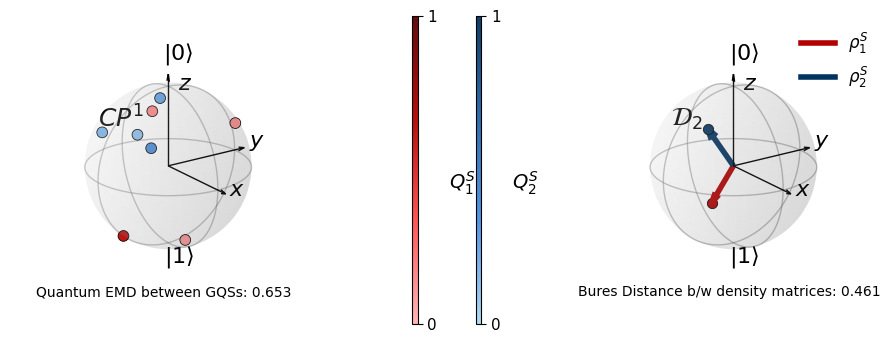

In [17]:
system_site = 0
# ________Reduced density matrices of the two Global States____________
rho1_s = rho_single_spin(dhilbert, nchain, system_site, psi1)
rho2_s = rho_single_spin(dhilbert, nchain, system_site, psi2)
Dr0 = bures_distance(rho1_s, rho2_s)
# ________Reduced Geometric quantum state at site-a____________
chi1_s,q1_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi1)
chi2_s,q2_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi2)
#________Wasserstein Distances between the two____________
Dl0 = Quantum_EMD(chi1_s,q1_s,chi2_s,q2_s)
_=plot_density_matrices_and_gqs_distances(states1=chi1_s, weights1=q1_s,states2=chi2_s,weights2=q2_s,
                                        Dist_rho = Dr0,Dist_GQS = Dl0)

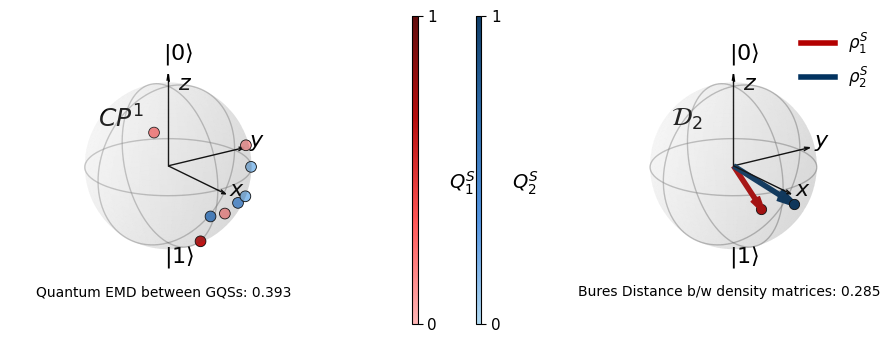

In [18]:
system_site = 1
# ________Reduced density matrices of the two Global States____________
rho1_s = rho_single_spin(dhilbert, nchain, system_site, psi1)
rho2_s = rho_single_spin(dhilbert, nchain, system_site, psi2)
Dr0 = bures_distance(rho1_s, rho2_s)
# ________Reduced Geometric quantum state at site-a____________
chi1_s,q1_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi1)
chi2_s,q2_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi2)
#________Wasserstein Distances between the two____________
Dl0 = Quantum_EMD(chi1_s,q1_s,chi2_s,q2_s)
_=plot_density_matrices_and_gqs_distances(states1=chi1_s, weights1=q1_s,states2=chi2_s,weights2=q2_s,
                                        Dist_rho = Dr0,Dist_GQS = Dl0)

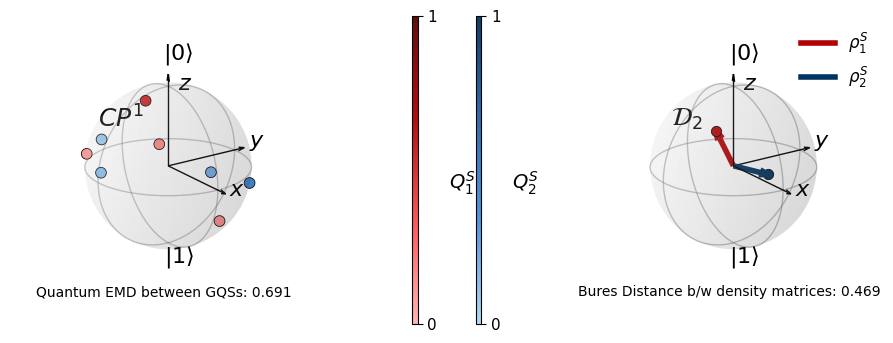

In [19]:
system_site = 2
# ________Reduced density matrices of the two Global States____________
rho1_s = rho_single_spin(dhilbert, nchain, system_site, psi1)
rho2_s = rho_single_spin(dhilbert, nchain, system_site, psi2)
Dr0 = bures_distance(rho1_s, rho2_s)
# ________Reduced Geometric quantum state at site-a____________
chi1_s,q1_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi1)
chi2_s,q2_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi2)
#________Wasserstein Distances between the two____________
Dl0 = Quantum_EMD(chi1_s,q1_s,chi2_s,q2_s)
_=plot_density_matrices_and_gqs_distances(states1=chi1_s, weights1=q1_s,states2=chi2_s,weights2=q2_s,
                                        Dist_rho = Dr0,Dist_GQS = Dl0)

### 1. Global Fubini-Study Distance - 4 Qubit System

In [20]:
dhilbert = 2
nchain = 4
psi1 = random_wavefunction(nchain)
print("Global State - 1")
print_wavefunction(psi1)
psi2 = random_wavefunction(nchain)
print("Global State - 2")
print_wavefunction(psi2)
print("\n \n Fubini-Study Distance between them: ",Psi_Dist(psi1,psi2))

Global State - 1
(-0.1199+0.0671j) |0000>     + (0.2048+0.2461j) |0001>      + (-0.2976-0.0905j) |0010>     + (-0.0554+0.2539j) |0011>     +
(-0.2462+0.3214j) |0100>     + (-0.0348+0.0718j) |0101>     + (-0.2103-0.0818j) |0110>     + (-0.1632-0.1776j) |0111>     +
(0.1741-0.0763j) |1000>      + (-0.0397+0.2749j) |1001>     + (0.1153+0.0961j) |1010>      + (0.1280+0.2360j) |1011>      +
(0.1450+0.2355j) |1100>      + (-0.2798-0.0255j) |1101>     + (0.1787-0.0994j) |1110>      + (0.1634+0.0561j) |1111>     
Global State - 2
(0.0508+0.1100j) |0000>      + (0.0418-0.2759j) |0001>      + (0.1013-0.0298j) |0010>      + (0.0975-0.1923j) |0011>      +
(-0.1039+0.1253j) |0100>     + (0.3357+0.1676j) |0101>      + (0.2606+0.2690j) |0110>      + (0.0154+0.0851j) |0111>      +
(-0.1905+0.0179j) |1000>     + (0.2016-0.3915j) |1001>      + (-0.0986-0.2003j) |1010>     + (-0.0458+0.0814j) |1011>     +
(-0.1030-0.0121j) |1100>     + (0.1532-0.2490j) |1101>      + (-0.2398-0.0068j) |1110>     + (-0.302

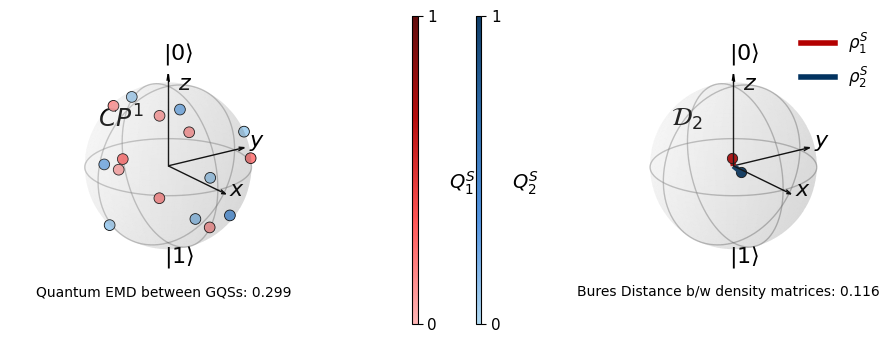

In [21]:
system_site = 0
# ________Reduced density matrices of the two Global States____________
rho1_s = rho_single_spin(dhilbert, nchain, system_site, psi1)
rho2_s = rho_single_spin(dhilbert, nchain, system_site, psi2)
Dr0 = bures_distance(rho1_s, rho2_s)
# ________Reduced Geometric quantum state at site-a____________
chi1_s,q1_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi1)
chi2_s,q2_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi2)
#________Wasserstein Distances between the two____________
Dl0 = Quantum_EMD(chi1_s,q1_s,chi2_s,q2_s)
_=plot_density_matrices_and_gqs_distances(states1=chi1_s, weights1=q1_s,states2=chi2_s,weights2=q2_s,
                                        Dist_rho = Dr0,Dist_GQS = Dl0)